In [1]:
# load necessary libraries 
import scanpy as sc
import matplotlib.pyplot as plt
import anndata as ad
import pandas as pd
import numpy as np
import gseapy as gp
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from scipy.stats import pearsonr

In [2]:
# load data (preprocessed from 'preprocessing.py')
adata = sc.read_h5ad("../data/frangieh/adata_preprocessed.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 190804 × 23711
    obs: 'library_preparation_protocol', 'condition', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'doublet_scores', 'predicted_doublets', 'doublet_info'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells',

# Selection of 50 pertubations 
To compare model generalizability, we select 50 perturbations using five distinct strategies:
* a) 50 most frequent pertubations 
* b) 50 randomly selected pertubations 
* c) 50 pertubations with highest LFC 
* d) cluster pertubations and select pertubations from each cluster -> most different 
* e) greedy algorithm: select 50 pertubations which exist in different pathways 


In [3]:
pertubation_counts = adata.obs[adata.obs['perturbation'] != 'control']['perturbation'].value_counts()
print(pertubation_counts)

# (a) 50 most frequent pertubations
top50_pertubations = pertubation_counts.head(50).index.tolist()

# (b) 50 randomly selected pertubations
np.random.seed(42)
all_pertubations = pertubation_counts.index.tolist()
random50_pertubations = list(np.random.choice(all_pertubations, size=50, replace=False))

perturbation
ACTA2      1215
B2M        1145
IFNGR2     1094
A2M        1092
AEBP1      1086
           ... 
AHCY         77
SNRPG        72
FARSA        65
RUVBL2       58
control       0
Name: count, Length: 238, dtype: int64


In [4]:
## (c) select 50 pertubations with the highest LFC in the control condition 
# calculate pseudo-bulk: mean profile per pertubation group
pertubation_bulk_adata = sc.get.aggregate(adata, by=['condition', 'perturbation'], func='mean', layer = "counts")
pertubation_bulk_adata.X = pertubation_bulk_adata.layers['mean'].copy()

df_expr = pertubation_bulk_adata.to_df()
df_obs = pertubation_bulk_adata.obs

In [5]:
# calculate lfc 
eps = 1

df_log_expr = np.log2(df_expr + eps)

ctrl_rows = df_obs[df_obs['perturbation'] == 'control'] # per condition unperturbed cells

# mean gene expression from control cells (no pertubation)
ctrl_control = df_log_expr.loc[ctrl_rows[ctrl_rows['condition'] == 'Control'].index].mean()
ctrl_IFN_gamma = df_log_expr.loc[ctrl_rows[ctrl_rows['condition'] == 'IFNγ'].index].mean()
ctrl_co_culture = df_log_expr.loc[ctrl_rows[ctrl_rows['condition'] == 'Co-culture'].index].mean()

# get cells with pertubations 
non_ctrl_obs = df_obs[df_obs['perturbation'] != 'control'].copy()
non_ctrl_lfc = df_log_expr.loc[non_ctrl_obs.index].copy()

# substracting baseline condition profile from expression of knockout per condition
for idx in non_ctrl_obs.index:
    condition = non_ctrl_obs.loc[idx, 'condition']
    if condition == 'Control':
        non_ctrl_lfc.loc[idx] -= ctrl_control
    elif condition == 'IFNγ':
        non_ctrl_lfc.loc[idx] -= ctrl_IFN_gamma
    elif condition == 'Co-culture':
        non_ctrl_lfc.loc[idx] -= ctrl_co_culture

log_fold_change_adata = ad.AnnData(X=non_ctrl_lfc.values, obs=non_ctrl_obs, var=pertubation_bulk_adata.var.copy())    

# filter for HVGs 
log_fold_change_adata_hvg = log_fold_change_adata[:, log_fold_change_adata.var['highly_variable']].copy()

In [6]:
# (c) selection of 50 pertubations according to their highest LFC 

mask_all_ctrl = log_fold_change_adata_hvg.obs['condition'] == 'Control'
df_lfc_ctrl = log_fold_change_adata_hvg[mask_all_ctrl].to_df()
df_lfc_ctrl.index = log_fold_change_adata_hvg[mask_all_ctrl].obs['perturbation']

# mean absolute LFC per Pertubation
mean_abs_lfc = df_lfc_ctrl.abs().mean(axis=1)
top_lfc50_pertubations = mean_abs_lfc.sort_values(ascending=False).head(50).index.tolist()

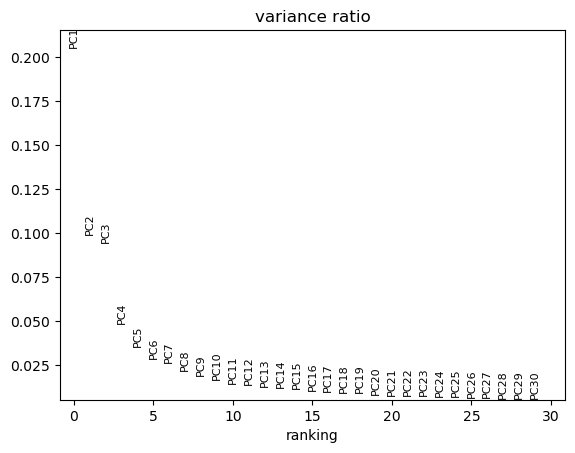

In [7]:
## (d) cluster pertubations and select pertubations from each cluster -> most different 
# PCA & Clustering of LFC-Matrix in control condition
adata_lfc_ctrl = log_fold_change_adata_hvg[log_fold_change_adata_hvg.obs['condition'] == 'Control'].copy()

# PCA
sc.pp.pca(adata_lfc_ctrl, n_comps=30)

# Elbow-Plot 
sc.pl.pca_variance_ratio(adata_lfc_ctrl, n_pcs=30, log=False)

In [15]:
#  n_pcs=7
sc.pp.pca(adata_lfc_ctrl, n_comps=7)

sc.pp.neighbors(adata_lfc_ctrl)
sc.tl.leiden(adata_lfc_ctrl, resolution=0.7)

/tmp/ipykernel_4100/2494350968.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_lfc_ctrl, resolution=0.7)


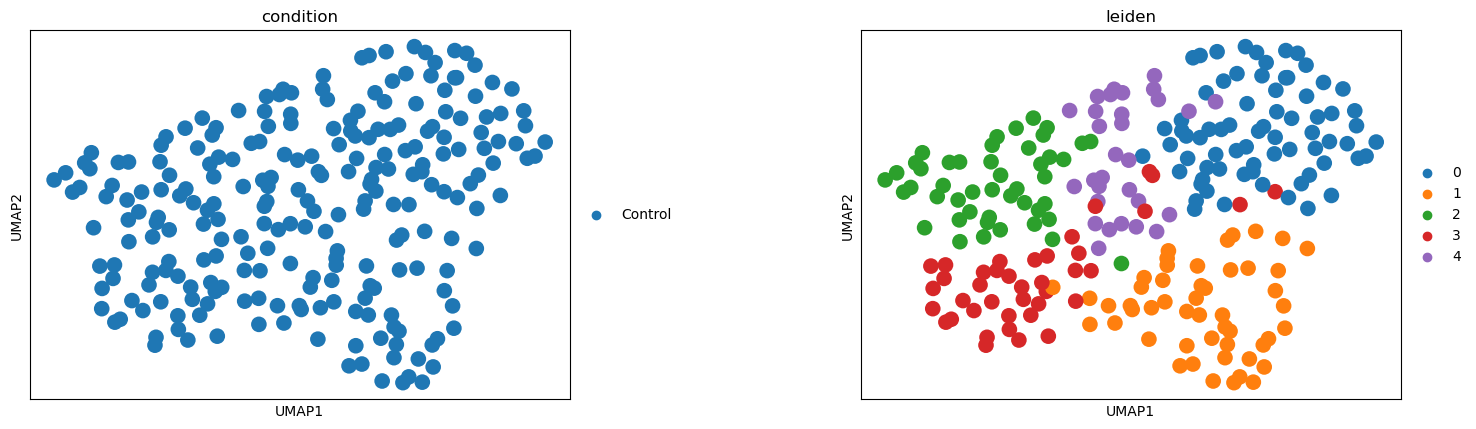

In [16]:
sc.tl.umap(adata_lfc_ctrl)
sc.pl.umap(adata_lfc_ctrl, color=['condition', 'leiden'], wspace=0.4)

In [17]:
# select 10 pertubations per cluster to get 50 pertubations 
np.random.seed(42)
cluster50_pertubations = []

for cluster_id in sorted(adata_lfc_ctrl.obs['leiden'].unique()):
    
    # get all pertubations per cluster
    cluster_perts = adata_lfc_ctrl.obs[adata_lfc_ctrl.obs['leiden'] == cluster_id]['perturbation'].unique().tolist()
    
    # select 10 random pertubations per cluster 
    n_samples = min(10, len(cluster_perts))
    chosen = np.random.choice(cluster_perts, size=n_samples, replace=False).tolist()
    cluster50_pertubations.extend(chosen)
    print(f"Cluster {cluster_id}: {len(chosen)} Perturbationen selected (out of {len(cluster_perts)} available ones)")

# if a cluster has less than 10 pertubations, select other pertubations to get 50 in total
if len(cluster50_pertubations) < 50:
    remaining = [p for p in adata_lfc_ctrl.obs['perturbation'].unique() if p not in cluster50_pertubations]
    needed = 50 - len(cluster50_pertubations)
    cluster50_pertubations.extend(np.random.choice(remaining, size=needed, replace=False).tolist())

print(f"\ntotal selected Knockouts: {len(cluster50_pertubations)}")

Cluster 0: 10 Perturbationen selected (out of 71 available ones)
Cluster 1: 10 Perturbationen selected (out of 50 available ones)
Cluster 2: 10 Perturbationen selected (out of 46 available ones)
Cluster 3: 10 Perturbationen selected (out of 40 available ones)
Cluster 4: 10 Perturbationen selected (out of 30 available ones)

total selected Knockouts: 50


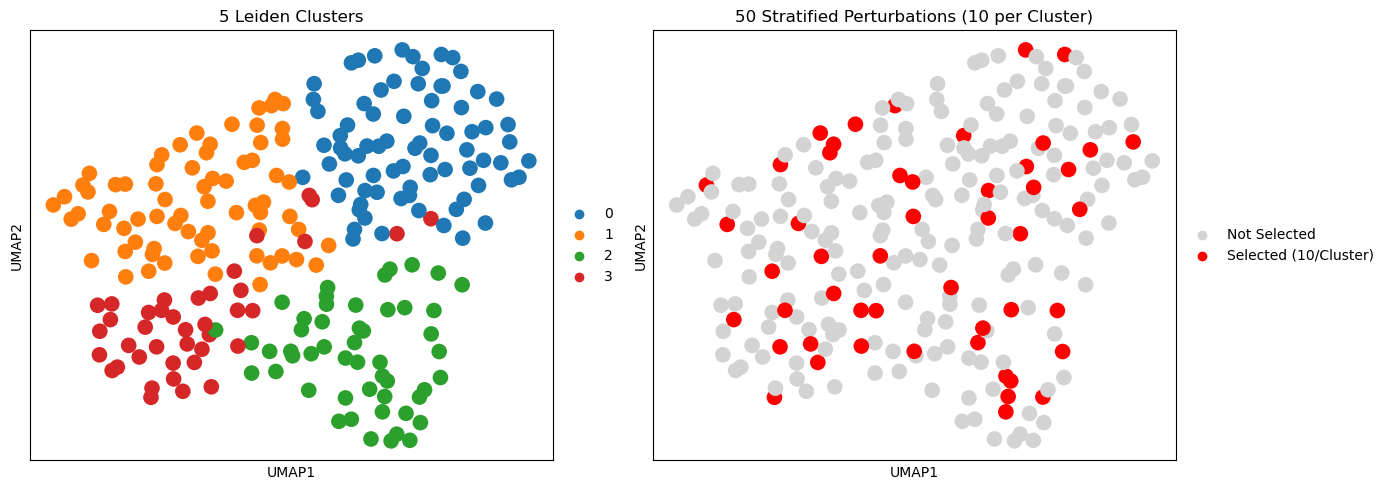

In [11]:
# visualization of 50 selected pertubations 
sc.tl.umap(adata_lfc_ctrl)

adata_lfc_ctrl.obs['selected_50'] = adata_lfc_ctrl.obs['perturbation'].apply(
    lambda x: 'Selected (10/Cluster)' if x in cluster50_pertubations else 'Not Selected'
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sc.pl.umap(adata_lfc_ctrl, color='leiden', ax=ax1, show=False, title='5 Leiden Clusters')
sc.pl.umap(
    adata_lfc_ctrl, 
    color='selected_50', 
    palette={'Selected (10/Cluster)': 'red', 'Not Selected': 'lightgrey'}, 
    ax=ax2, 
    show=False, 
    title='50 Stratified Perturbations (10 per Cluster)'
)

plt.tight_layout()
plt.show()

In [18]:
## (e) greedy algorithm: select 50 pertubations which exist in different pathways 
# load hallmark pathways 
hallmark = gp.get_library(name="MSigDB_Hallmark_2020", organism="Human")

hallmark_upper = {pathway: {str(g).upper() for g in genes} for pathway, genes in hallmark.items()}

In [19]:
eligible_genes = all_pertubations

pathway_matrix = pd.DataFrame(0, index=eligible_genes, columns=hallmark_upper.keys(), dtype=int)
for gene in eligible_genes:
    g_up = str(gene).upper()
    for pathway, p_genes in hallmark_upper.items():
        if g_up in p_genes:
            pathway_matrix.loc[gene, pathway] = 1


In [20]:
rng = np.random.default_rng(42)
annotated_genes = pathway_matrix.index[pathway_matrix.sum(axis=1) > 0].tolist()

pathway50_pertubations = []
covered_pathways = set()
remaining = annotated_genes.copy()

while len(pathway50_pertubations) < 50 and len(remaining) > 0:
    gains = {}
    for gene in remaining:
        gene_pathways = set(pathway_matrix.columns[pathway_matrix.loc[gene] == 1])
        new_pathways = gene_pathways - covered_pathways
        gains[gene] = len(new_pathways)
        
    max_gain = max(gains.values())
    
    # if no gene is found in a new pathway, stop loop
    if max_gain == 0:
        break
        
    best_genes = [g for g, gain in gains.items() if gain == max_gain]
    chosen = rng.choice(best_genes)
    
    pathway50_pertubations.append(chosen)
    covered_pathways.update(pathway_matrix.columns[pathway_matrix.loc[chosen] == 1])
    remaining.remove(chosen)

# if < 50 Gene: fill with remaining genes
if len(pathway50_pertubations) < 50:
    extra_candidates = [g for g in eligible_genes if g not in pathway50_pertubations]
    extra = rng.choice(extra_candidates, size=50 - len(pathway50_pertubations), replace=False)
    pathway50_pertubations.extend(extra.tolist())

print(f"selected genes: {len(pathway50_pertubations)}")
print(f"covered Hallmark-pathways: {pathway_matrix.loc[pathway50_pertubations].max(axis=0).sum()} / 50")


selected genes: 50
covered Hallmark-pathways: 46 / 50
